In [7]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv
import re

rho_ratio = '10'
v = '001'
U='0.01'
Uf=float(U)
Ustr=re.sub("\.", '', U)

folder_path = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble",
                           f"rho{rho_ratio}_v{v}_circular_U{Ustr}",
                          "line_data")

n = 999  # last time-frame

cm_ux_std = np.empty(n)
mrt_ux_std = np.empty(n)

frames_cm_moving = []
frames_mrt_moving = []

for i in range(n):
    def load_data(path):
        try:
            frame_moving = pd.read_csv(path, delimiter=",")      
            std = np.sqrt(sum((frame_moving['U:0'] - Uf) * (frame_moving['U:0'] - Uf)) / len(frame_moving['U:0']))   
            return std     
        except FileNotFoundError:
            print(f"Wrong file or file path: {path}")
            return None
                     
    mrt_ux_std[i] = load_data(os.path.join(folder_path, f"mrt_moving.{i}.csv"))    
    cm_ux_std[i] = load_data(os.path.join(folder_path, f"cm_moving.{i}.csv"))       


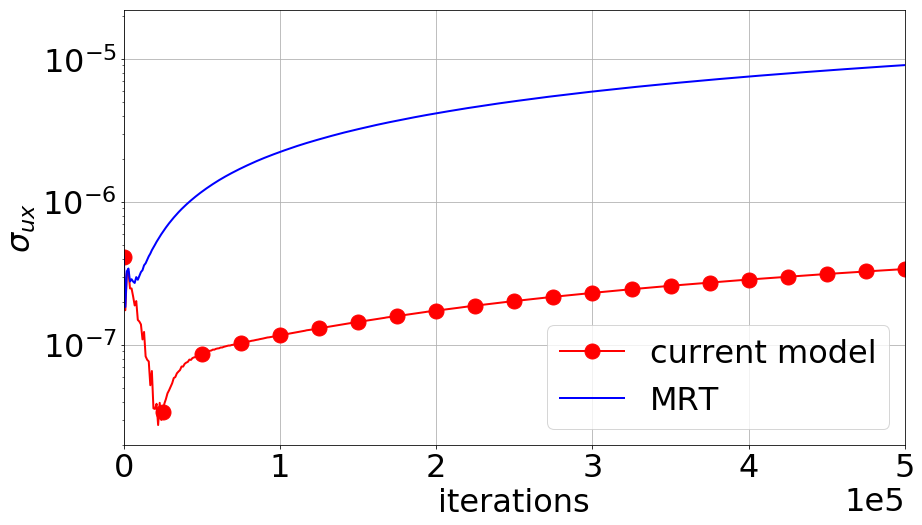

In [8]:
# make plot
def make_plot(x1, y1, x2, y2, fig_name, y_label):
    plt.rcParams.update({'font.size': 32})
    plt.figure(figsize=(14, 8))
        
    plt.plot(x1, y1, color="red", marker="o", markevery=25,  markersize=15, linestyle="-", linewidth=2, label='current model')
    plt.plot(x2, y2, color="blue", marker="", linestyle="-", linewidth=2, label='MRT')
    plt.yscale('log')
    axes = plt.gca()
    axes.set_xlim([0,0.5*1E6])
    # axes.set_xlim([xmin,xmax])
    # axes.set_ylim([-3E-7, 3E-7])
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
#     plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.xlabel(r'iterations')
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    
    fig = plt.gcf()  # get current figure
    fig.savefig(fig_name )
    plt.show()
    plt.close(fig)    # close the figure
    

make_plot(x1=np.arange(n)*1E3, y1=cm_ux_std,
          x2=np.arange(n)*1E3, y2=mrt_ux_std,
          fig_name=f'sigma_ux_rho{rho_ratio}_v{v}_U{Ustr}_log.png' ,
          y_label=r'$\sigma_{ux}$'
         )
    